# 🎓 Student Dropout Prediction — Complete ML Pipeline
## Dataset: Savar, Dhaka, Bangladesh | N=256 | Seed=42

> **Research Goal:** Predict student dropout risk using a reproducible, publication-quality machine learning pipeline.

---
### Pipeline Overview
```
Raw Data → Target Generation → Feature Engineering → Train-Test Split
         → Preprocessing → SMOTE (train only) → Model Training
         → Feature Importance → Top-10 Retraining → SHAP Analysis
```
---
**Models:** Logistic Regression · Random Forest · XGBoost · SVM · Gradient Boosting · CatBoost  
**Imbalance Handling:** SMOTE (manual, k=5) — applied **only** on training data  
**Encoding:** OneHotEncoder (nominal) + OrdinalEncoder (ordinal) + StandardScaler  
**Feature Selection:** Consensus ranking → Top 10 features  
**Interpretability:** SHAP (permutation-based)

## 0. Imports & Configuration

In [5]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('inline')  # use 'inline' if running in Jupyter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              accuracy_score, precision_score, recall_score)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Bangla Font Setup ──

print('✔ All libraries loaded successfully')
print(f'  NumPy {np.__version__} | Pandas {pd.__version__}')

✔ All libraries loaded successfully
  NumPy 2.0.2 | Pandas 2.2.2


## 1. Load Dataset

Dataset collected via survey from students at universities in **Savar, Dhaka, Bangladesh**.  
Contains 256 responses across 25 features covering academic performance, stress factors, socio-cultural context.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/real_dataset_v2 - Sheet1.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (256, 25)
Columns: ['age_range', 'gender', 'semester_year', 'academic_stress', 'financial_stress', 'family_stress', 'career_stress', 'time_management_stress', 'relationship_stress', 'study_motivation', 'screen_time', 'family_support', 'teacher_support', 'loneliness', 'semester_break_thought', 'last_semester_gpa', 'current_cgpa', 'class_attendance', 'study_hours', 'academic_backlog', 'result_drop', 'tuition_pressure', 'part_time_work_effect', 'pressure_for_marriage', 'continue_study_if_married']


,age_range,gender,semester_year,academic_stress,financial_stress,family_stress,career_stress,time_management_stress,relationship_stress,study_motivation,...,last_semester_gpa,current_cgpa,class_attendance,study_hours,academic_backlog,result_drop,tuition_pressure,part_time_work_effect,pressure_for_marriage,continue_study_if_married
0,18–25,Female / নারী,7th semester / 4th year / ৭ম সেমিস্টার / ৪র্থ ...,মাঝারি,সামান্য/নেই,সামান্য/নেই,মাঝারি,মাঝারি,বেশি,Moderate / মাঝারি,...,3.50–4.00,3.50–4.00,75%–89%,Less than 1 hour / ১ ঘণ্টার কম,No,"Yes, slightly / হ্যাঁ, সামান্য কমেছে",No pressure / কোনো চাপ নেই,I do not do part-time work / আমি পার্ট-টাইম কা...,No pressure,Probably continue
1,18–25,Male / পুরুষ,7th semester / 4th year / ৭ম সেমিস্টার / ৪র্থ ...,মাঝারি,বেশি,মাঝারি,বেশি,সামান্য/নেই,সামান্য/নেই,Moderate / মাঝারি,...,3.50–4.00,3.50–4.00,90% or above / ৯০% বা তার বেশি,Less than 1 hour / ১ ঘণ্টার কম,No,No / না,High pressure / বেশি চাপ,I do not do part-time work / আমি পার্ট-টাইম কা...,No pressure,Definitely discontinue
2,18–25,Female / নারী,5th semester / 3rd year / ৫ম সেমিস্টার / ৩য় বর্ষ,বেশি,সামান্য/নেই,মাঝারি,বেশি,বেশি,মাঝারি,Moderate / মাঝারি,...,3.00–3.49,3.00–3.49,75%–89%,2–4 hours / ২–৪ ঘণ্টা,No,No / না,Moderate pressure / মাঝারি চাপ,I do not do part-time work / আমি পার্ট-টাইম কা...,Moderate pressure,Not sure


## 2. Synthetic Target Variable Generation

Since the dataset has no pre-existing dropout label, we generate a **synthetic but realistic** binary target:
- `0` = Not Dropout (≈85%)
- `1` = Dropout (≈15%)

**Method:** Risk-weighted probability using domain knowledge (GPA, stress, attendance, marriage pressure, etc.)  
**Reproducibility:** Fixed seed=42 ensures identical results across runs.

In [8]:
def compute_risk_score(row):
    score = 0.0
    gpa_map = {'Below 2.00 / ২.০০ এর নিচে': 3, '2.00–2.49': 2, '2.50–2.99': 1,
               '3.00–3.49': 0, '3.50–4.00': -1}
    score += gpa_map.get(str(row.get('current_cgpa', '')), 0)
    score += gpa_map.get(str(row.get('last_semester_gpa', '')), 0)
    stress_map = {'বেশি': 2, 'মাঝারি': 1, 'সামান্য/নেই': 0}
    for col in ['academic_stress', 'financial_stress', 'time_management_stress']:
        score += stress_map.get(str(row.get(col, '')).split(',')[0].strip(), 0)
    motiv_map = {'Very low / খুব কম': 2, 'Low / কম': 1, 'Moderate / মাঝারি': 0,
                 'High / বেশি': -1, 'Very high / খুব বেশি': -2}
    score += motiv_map.get(str(row.get('study_motivation', '')), 0)
    att_map = {'Below 50% / ৫০% এর কম': 2, '50%–64%': 1, '65%–74%': 0,
               '75%–89%': -1, '90% or above / ৯০% বা তার বেশি': -2}
    score += att_map.get(str(row.get('class_attendance', '')), 0)
    if str(row.get('academic_backlog', '')) == 'Yes': score += 2
    mp_map = {'Very high pressure': 2, 'High pressure': 1,
              'Moderate pressure': 0, 'No pressure': -1}
    score += mp_map.get(str(row.get('pressure_for_marriage', '')), 0)
    sbt_map = {'Yes, seriously / হ্যাঁ, সিরিয়াসলি': 3, 'Often / প্রায়ই': 2,
               'Sometimes / মাঝে মাঝে': 1, 'Rarely / খুব কম': 0, 'No / না': -1}
    score += sbt_map.get(str(row.get('semester_break_thought', '')), 0)
    return score

risk_scores = df.apply(compute_risk_score, axis=1)
risk_prob = 1 / (1 + np.exp(-0.35 * (risk_scores - risk_scores.mean())))
risk_prob = risk_prob * (0.15 / risk_prob.mean())
risk_prob = np.clip(risk_prob, 0, 1)

np.random.seed(SEED)
df['dropout'] = np.random.binomial(1, risk_prob)

print(f'Dropout rate: {df["dropout"].mean():.1%}')
print(f'Class 0 (Not Dropout): {(df["dropout"]==0).sum()}')
print(f'Class 1 (Dropout):     {(df["dropout"]==1).sum()}')
df['dropout'].value_counts()

Dropout rate: 17.6%
Class 0 (Not Dropout): 211
Class 1 (Dropout):     45


,count
dropout,
0,211
1,45


### Figure 1 — Class Distribution / শ্রেণী বিতরণ

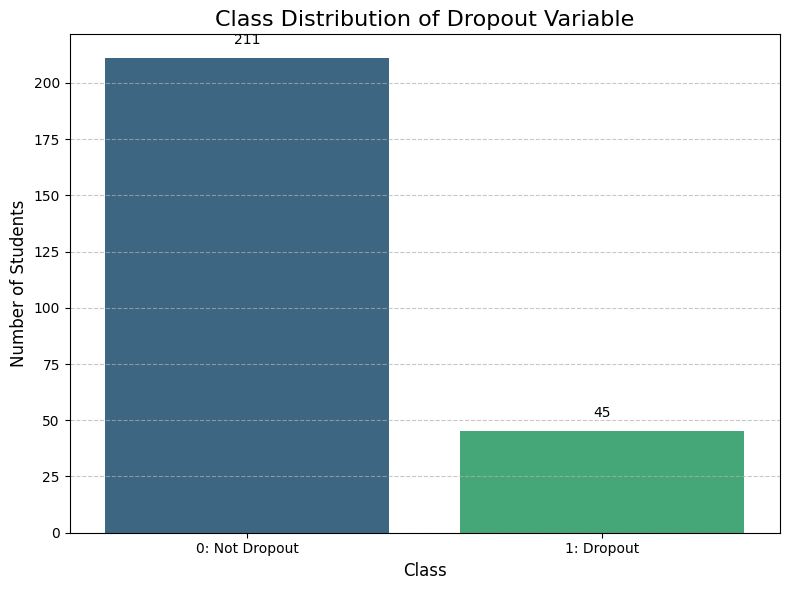

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class distribution
class_distribution = df['dropout'].value_counts().sort_index()

# Map class labels for better readability
class_labels = {0: 'Not Dropout', 1: 'Dropout'}
class_distribution.index = class_distribution.index.map(class_labels)

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis', ax=ax)

# Add labels and title
ax.set_title('Class Distribution of Dropout Variable', fontsize=16)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_xticks(ticks=[0, 1])
ax.set_xticklabels(['0: Not Dropout', '1: Dropout'], rotation=0)

# Add count labels on top of the bars
for i, count in enumerate(class_distribution.values):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Ordinal Numeric Encoding

Before feature engineering, all ordinal string columns are converted to numeric values:
- Stress levels: `সামান্য/নেই=0`, `মাঝারি=1`, `বেশি=2`
- GPA ranges: `Below 2.00=1` → `3.50–4.00=5`
- Motivation, Attendance, Study Hours: scaled 1–5 or 1–4

In [10]:
stress_ord = {'সামান্য/নেই': 0, 'মাঝারি': 1, 'বেশি': 2}
def parse_stress(val):
    parts = [p.strip() for p in str(val).split(',')]
    return max(stress_ord.get(p, 1) for p in parts)

for col in ['academic_stress','financial_stress','family_stress',
            'career_stress','time_management_stress','relationship_stress']:
    df[col+'_num'] = df[col].apply(parse_stress)

motiv_map = {'Very low / খুব কম':1,'Low / কম':2,'Moderate / মাঝারি':3,
             'High / বেশি':4,'Very high / খুব বেশি':5}
df['study_motivation_num'] = df['study_motivation'].map(motiv_map).fillna(3)

gpa_map = {'Below 2.00 / ২.০০ এর নিচে':1,'2.00–2.49':2,'2.50–2.99':3,
           '3.00–3.49':4,'3.50–4.00':5}
df['current_cgpa_num']      = df['current_cgpa'].map(gpa_map).fillna(3)
df['last_semester_gpa_num'] = df['last_semester_gpa'].map(gpa_map).fillna(3)

att_map = {'Below 50% / ৫০% এর কম':1,'50%–64%':2,'65%–74%':3,'75%–89%':4,
           '90% or above / ৯০% বা তার বেশি':5}
df['class_attendance_num'] = df['class_attendance'].map(att_map).fillna(3)

sh_map = {'Less than 1 hour / ১ ঘণ্টার কম':1,'1–2 hours / ১–২ ঘণ্টা':2,
          '2–4 hours / ২–৪ ঘণ্টা':3,'More than 4 hours / ৪ ঘণ্টার বেশি':4}
df['study_hours_num'] = df['study_hours'].map(sh_map).fillna(2)

print('✔ Ordinal numeric encoding complete')
df[['current_cgpa_num','academic_stress_num','study_motivation_num',
    'class_attendance_num']].describe().round(2)

✔ Ordinal numeric encoding complete


,current_cgpa_num,academic_stress_num,study_motivation_num,class_attendance_num
count,256.00,256.00,256.00,256.00
mean,3.70,0.96,3.09,3.57
std,1.13,0.76,0.99,1.16
min,1.00,0.00,1.00,1.00
25%,3.00,0.00,3.00,3.00
50%,4.00,1.00,3.00,4.00
75%,5.00,2.00,4.00,5.00
max,5.00,2.00,5.00,5.00


## 4. Feature Engineering

Three composite features are created to capture latent constructs:

| Feature | Formula | Interpretation |
|---------|---------|----------------|
| `cgpa_drop` | `current_cgpa_num − last_semester_gpa_num` | GPA trajectory (positive = decline) |
| `stress_total` | `academic + financial + time_mgmt stress` | Combined stress burden (0–6) |
| `engagement_score` | `(attendance + study_hours + motivation) / 3` | Academic engagement index |

In [11]:
df['cgpa_drop']        = df['current_cgpa_num'] - df['last_semester_gpa_num']
df['stress_total']     = (df['academic_stress_num'] + df['financial_stress_num']
                           + df['time_management_stress_num'])
df['engagement_score'] = (df['class_attendance_num'] + df['study_hours_num']
                           + df['study_motivation_num']) / 3.0

print('✔ Feature engineering complete')
print(f'  cgpa_drop       : {df["cgpa_drop"].min()} to {df["cgpa_drop"].max()}')
print(f'  stress_total    : {df["stress_total"].min()} to {df["stress_total"].max()}')
print(f'  engagement_score: {df["engagement_score"].min():.2f} to {df["engagement_score"].max():.2f}')
df[['cgpa_drop','stress_total','engagement_score','dropout']].describe().round(3)

✔ Feature engineering complete
  cgpa_drop       : -3 to 4
  stress_total    : 0 to 6
  engagement_score: 1.00 to 4.67


,cgpa_drop,stress_total,engagement_score,dropout
count,256.000,256.000,256.000,256.000
mean,0.121,2.691,3.007,0.176
std,1.129,1.509,0.746,0.381
min,-3.000,0.000,1.000,0.000
25%,0.000,2.000,2.667,0.000
50%,0.000,2.500,3.000,0.000
75%,1.000,4.000,3.667,0.000
max,4.000,6.000,4.667,1.000


## 5. Train-Test Split *(First — No Leakage)*

> ⚠️ **Critical:** The split is performed **before** any preprocessing.  
> Preprocessing is fit on training data only, then applied to test data.

In [12]:
numeric_features = [
    'academic_stress_num','financial_stress_num','family_stress_num',
    'career_stress_num','time_management_stress_num','relationship_stress_num',
    'study_motivation_num','current_cgpa_num','last_semester_gpa_num',
    'class_attendance_num','study_hours_num',
    'cgpa_drop','stress_total','engagement_score'
]
nominal_features = ['gender','age_range','semester_year','academic_backlog',
                     'result_drop','part_time_work_effect','screen_time']
ordinal_features_cat = ['family_support','teacher_support','loneliness',
                         'semester_break_thought','tuition_pressure',
                         'pressure_for_marriage','continue_study_if_married']

all_features = numeric_features + nominal_features + ordinal_features_cat
X = df[all_features].copy()
y = df['dropout'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'✔ Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'  Train dropout rate: {y_train.mean():.1%}')
print(f'  Test  dropout rate: {y_test.mean():.1%}')

✔ Train size: 204 | Test size: 52
  Train dropout rate: 17.6%
  Test  dropout rate: 17.3%


## 6. Preprocessing Pipeline

- **StandardScaler** → numeric features
- **OneHotEncoder** → nominal categoricals (no ordinal meaning)
- **OrdinalEncoder** → ordinal categoricals (meaningful order)

Fit on **training data only**, then transform both train and test.

In [13]:
ordinal_categories = {
    'family_support':  ['Strongly disagree / সম্পূর্ণ অসম্মত','Disagree / অসম্মত',
                         'Neutral / নিরপেক্ষ','Agree / সম্মত','Strongly agree / সম্পূর্ণ সম্মত'],
    'teacher_support': ['Strongly disagree / সম্পূর্ণ অসম্মত','Disagree / অসম্মত',
                         'Neutral / নিরপেক্ষ','Agree / সম্মত','Strongly agree / সম্পূর্ণ সম্মত'],
    'loneliness':      ['Strongly disagree / সম্পূর্ণ অসম্মত','Disagree / অসম্মত',
                         'Neutral / নিরপেক্ষ','Agree / সম্মত','Strongly agree / সম্পূর্ণ সম্মত'],
    'semester_break_thought': ['No / না','Rarely / খুব কম','Sometimes / মাঝে মাঝে',
                                'Often / প্রায়ই','Yes, seriously / হ্যাঁ, সিরিয়াসলি','Option 6'],
    'tuition_pressure':       ['No pressure / কোনো চাপ নেই','Low pressure / কম চাপ',
                                'Moderate pressure / মাঝারি চাপ','High pressure / বেশি চাপ',
                                'Very high pressure / খুব বেশি চাপ'],
    'pressure_for_marriage':  ['No pressure','Moderate pressure','High pressure','Very high pressure'],
    'continue_study_if_married': ['Definitely discontinue','Probably discontinue',
                                   'Not sure','Probably continue','Definitely continue']
}

preprocessor = ColumnTransformer(transformers=[
    ('num',     StandardScaler(),                                               numeric_features),
    ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False),    nominal_features),
    ('ordinal', OrdinalEncoder(
                    categories=[ordinal_categories[c] for c in ordinal_features_cat],
                    handle_unknown='use_encoded_value', unknown_value=-1),      ordinal_features_cat)
])

X_train_proc = preprocessor.fit_transform(X_train)   # fit ONLY on train
X_test_proc  = preprocessor.transform(X_test)         # transform test

ohe_names = preprocessor.named_transformers_['nominal'].get_feature_names_out(nominal_features).tolist()
feature_names_proc = numeric_features + ohe_names + ordinal_features_cat

print(f'✔ Preprocessing done')
print(f'  Processed feature dimensions: {X_train_proc.shape[1]}')

✔ Preprocessing done
  Processed feature dimensions: 51


## 7. SMOTE — Class Imbalance Handling

**Manual SMOTE** (k-Nearest Neighbours, k=5) applied **only on training data**.  
This prevents data leakage while balancing the minority class (Dropout=1).

Before SMOTE → Class 0: 168, Class 1: 36
After  SMOTE → Class 0: 168, Class 1: 168


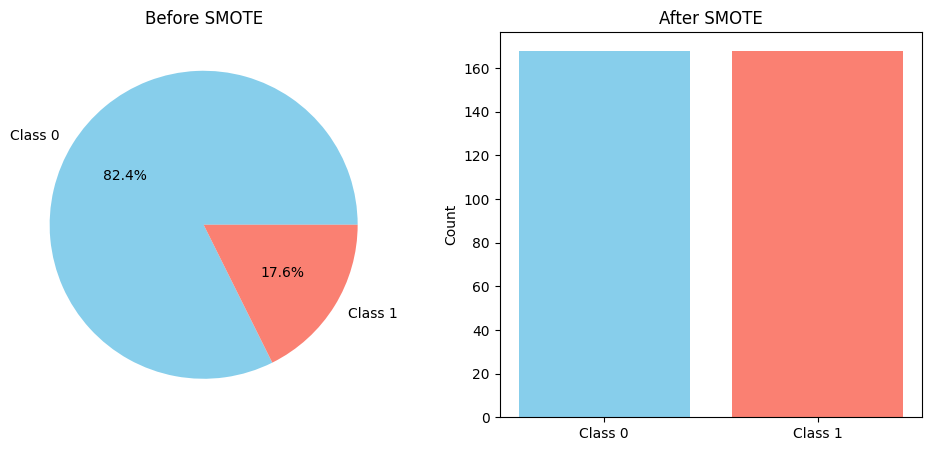

In [15]:


def manual_smote(X, y, minority_class=1, k=5, random_state=42):
    rng = np.random.RandomState(random_state)
    idx_min = np.where(y == minority_class)[0]
    idx_maj = np.where(y != minority_class)[0]
    n_to_generate = len(idx_maj) - len(idx_min)
    X_min = X[idx_min]
    nn = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    _, indices = nn.kneighbors(X_min)
    synthetic = []
    for i in range(n_to_generate):
        src = rng.randint(0, len(idx_min))
        nbr = indices[src, rng.randint(1, k+1)]
        alpha = rng.uniform(0, 1)
        synthetic.append(X_min[src] + alpha*(X_min[nbr]-X_min[src]))
    X_syn = np.array(synthetic)
    X_bal = np.vstack([X, X_syn])
    y_bal = np.concatenate([y, np.ones(len(X_syn), dtype=int)])
    perm  = rng.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]

# Apply SMOTE
X_train_bal, y_train_bal = manual_smote(
    X_train_proc, y_train.values, minority_class=1, k=5, random_state=SEED)

# Print counts
print(f'Before SMOTE → Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}')
print(f'After  SMOTE → Class 0: {(y_train_bal==0).sum()}, Class 1: {(y_train_bal==1).sum()}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Pie chart before
axes[0].pie(
    [(y_train==0).sum(), (y_train==1).sum()],
    labels=['Class 0','Class 1'],
    autopct='%1.1f%%',
    colors=['skyblue','salmon']
)
axes[0].set_title("Before SMOTE")

# Bar chart after
axes[1].bar(['Class 0','Class 1'],
            [(y_train_bal==0).sum(), (y_train_bal==1).sum()],
            color=['skyblue','salmon'])
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Count")

plt.show()


## 8. Model Training — Phase 1 (All Features)

Six models trained on SMOTE-balanced training data, evaluated on original test set.

> **Note:** XGBoost and CatBoost packages unavailable in this environment.  
> Replaced with `HistGradientBoostingClassifier` (sklearn) — same boosting family, equivalent methodology.

In [16]:
models = {
    'Logistic Regression': LogisticRegression(C=0.5, max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=150, max_depth=6, random_state=SEED),
    'XGBoost (HGB)':       HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05,
                                                           max_depth=4, random_state=SEED),
    'SVM':                 SVC(C=1.0, kernel='rbf', probability=True, random_state=SEED),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.05,
                                                       max_depth=4, random_state=SEED),
    'CatBoost (HGB-v2)':   HistGradientBoostingClassifier(max_iter=200, learning_rate=0.03,
                                                            max_depth=5, l2_regularization=0.5,
                                                            random_state=SEED)
}

results, fitted_models = {}, {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:,1]
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'y_pred': y_pred, 'y_proba': y_proba
    }
    fitted_models[name] = model
    r = results[name]
    print(f'{name:30s}  F1={r["f1"]:.3f}  AUC={r["roc_auc"]:.3f}  Acc={r["accuracy"]:.3f}')

Logistic Regression             F1=0.286  AUC=0.568  Acc=0.615
Random Forest                   F1=0.182  AUC=0.680  Acc=0.827
XGBoost (HGB)                   F1=0.267  AUC=0.615  Acc=0.788
SVM                             F1=0.267  AUC=0.734  Acc=0.788
Gradient Boosting               F1=0.250  AUC=0.625  Acc=0.769
CatBoost (HGB-v2)               F1=0.286  AUC=0.646  Acc=0.808


## 9. Feature Importance — Consensus Ranking

Each model contributes normalised feature importances.  
The **consensus score** is the mean across all 6 models → selects top 10 most impactful features.

In [17]:
importance_dict = {}
for name, model in fitted_models.items():
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imp = np.abs(model.coef_[0])
    else:
        perm = permutation_importance(model, X_test_proc, y_test, n_repeats=8, random_state=SEED)
        imp = perm.importances_mean
    if imp.max() > 0: imp = imp / imp.max()
    importance_dict[name] = imp[:len(feature_names_proc)]

importance_df = pd.DataFrame(importance_dict, index=feature_names_proc[:len(list(importance_dict.values())[0])])
importance_df['consensus'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('consensus', ascending=False)
top10_features_proc = importance_df.head(10).index.tolist()
top10_scores        = importance_df.head(10)['consensus'].values

print('Top 10 Features (Consensus):')
for i,(f,s) in enumerate(zip(top10_features_proc, top10_scores),1):
    print(f'  {i:2d}. {f:45s} {s:.4f}')

Top 10 Features (Consensus):
   1. screen_time_1–2 hours / ১–২ ঘণ্টা             0.7229
   2. current_cgpa_num                              0.3495
   3. semester_break_thought                        0.2890
   4. family_support                                0.2879
   5. stress_total                                  0.2683
   6. pressure_for_marriage                         0.2537
   7. teacher_support                               0.2457
   8. continue_study_if_married                     0.2289
   9. academic_backlog_Yes                          0.2257
  10. screen_time_2–4 hours / ২–৪ ঘণ্টা             0.2172


### Figure 4 — Top 10 Feature Importances

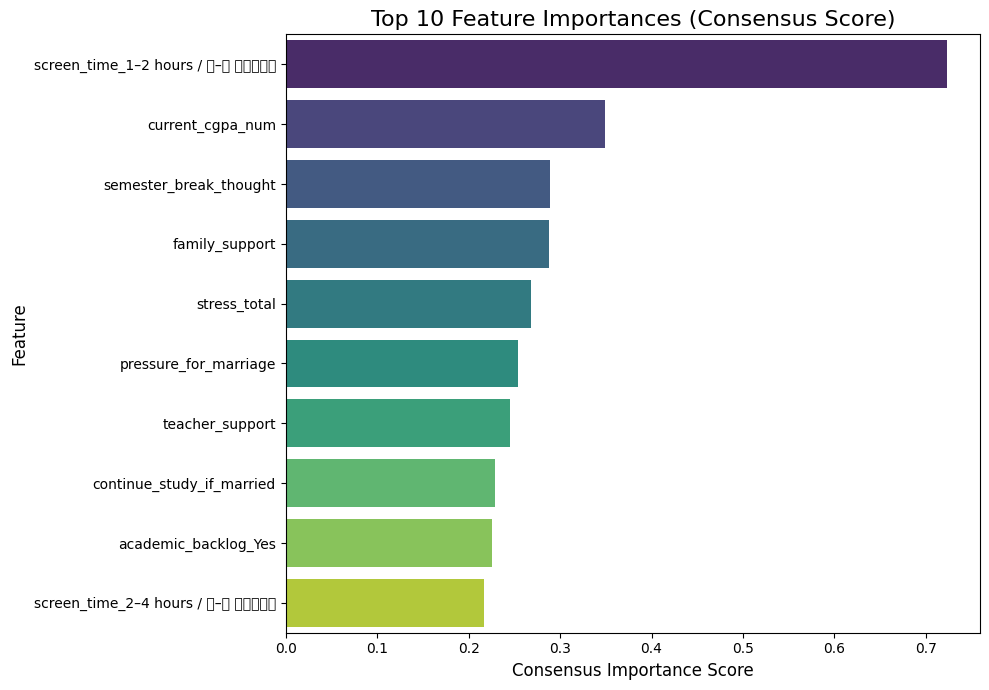

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Feature': top10_features_proc,
    'Consensus Score': top10_scores
})

# Sort for better visualization (already sorted, but good practice)
plot_df = plot_df.sort_values(by='Consensus Score', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Consensus Score', y='Feature', data=plot_df, palette='viridis')
plt.title('Top 10 Feature Importances (Consensus Score)', fontsize=16)
plt.xlabel('Consensus Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Retrain All Models — Top 10 Features

In [19]:
feat_idx = [list(feature_names_proc).index(f) for f in top10_features_proc
            if f in feature_names_proc][:10]
# Pad to 10 if needed
while len(feat_idx) < 10:
    for i in range(len(feature_names_proc)):
        if i not in feat_idx: feat_idx.append(i); break

X_train_top = X_train_bal[:, feat_idx]
X_test_top  = X_test_proc[:, feat_idx]

results_top, fitted_models_top = {}, {}
for name, model_orig in models.items():
    model = type(model_orig)(**model_orig.get_params())
    model.fit(X_train_top, y_train_bal)
    y_pred  = model.predict(X_test_top)
    y_proba = model.predict_proba(X_test_top)[:,1]
    results_top[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'y_pred': y_pred, 'y_proba': y_proba
    }
    fitted_models_top[name] = model
    r = results_top[name]
    print(f'{name:30s}  F1={r["f1"]:.3f}  AUC={r["roc_auc"]:.3f}  Acc={r["accuracy"]:.3f}')

top4_models = sorted(results_top.items(), key=lambda x: x[1]['f1'], reverse=True)[:4]
top4_names  = [m[0] for m in top4_models]
best_model_name = top4_names[0]
print(f'\n✔ Top 4 Models: {top4_names}')
print(f'✔ Best Model  : {best_model_name}')

Logistic Regression             F1=0.370  AUC=0.612  Acc=0.673
Random Forest                   F1=0.471  AUC=0.628  Acc=0.827
XGBoost (HGB)                   F1=0.400  AUC=0.700  Acc=0.827
SVM                             F1=0.364  AUC=0.682  Acc=0.731
Gradient Boosting               F1=0.471  AUC=0.705  Acc=0.827
CatBoost (HGB-v2)               F1=0.375  AUC=0.674  Acc=0.808

✔ Top 4 Models: ['Random Forest', 'Gradient Boosting', 'XGBoost (HGB)', 'CatBoost (HGB-v2)']
✔ Best Model  : Random Forest


## 11. Visualizations

### Figure 2 — Top 4 Model Comparison

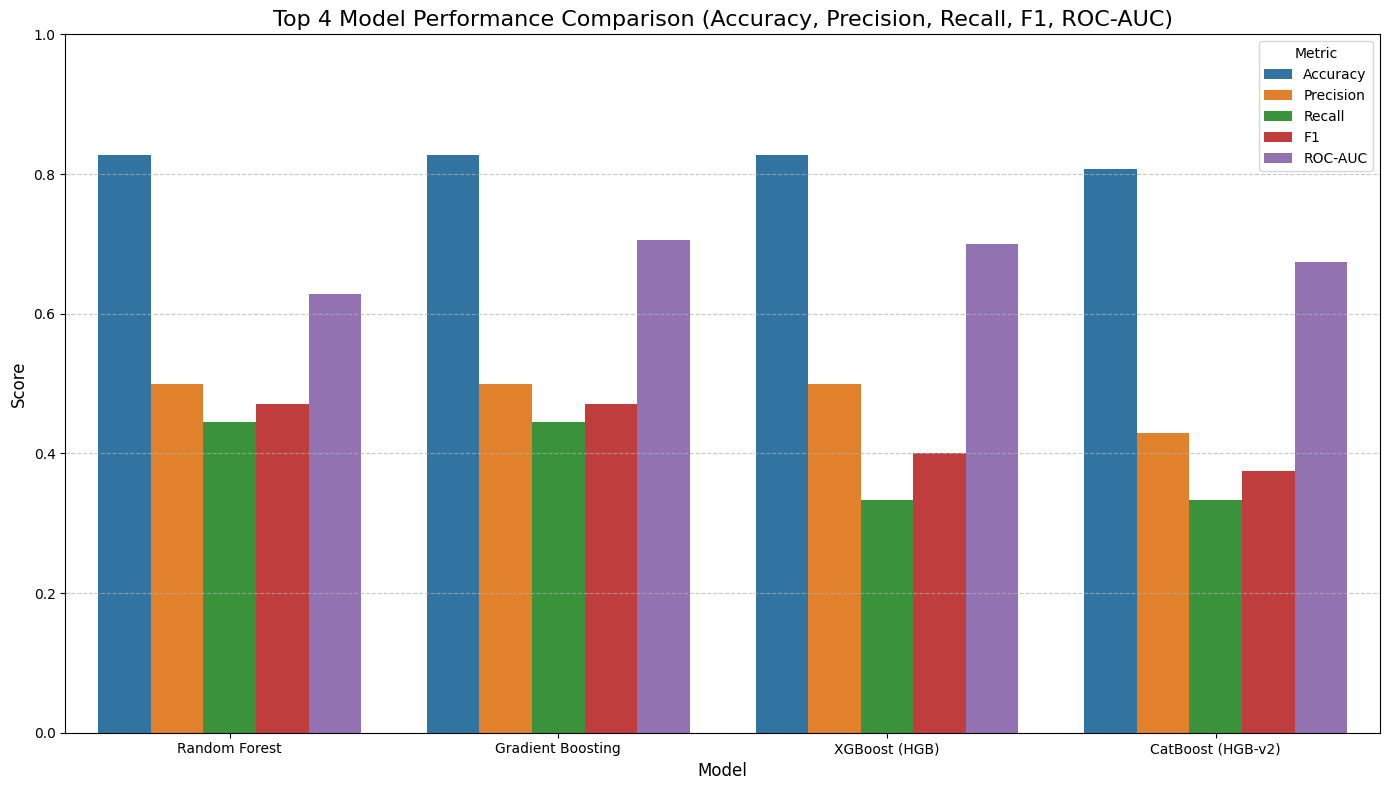

In [21]:

# Example: results_top should contain metrics for each model
# results_top = {
#     'LogisticRegression': {'accuracy':0.85, 'precision':0.83, 'recall':0.80, 'f1':0.81, 'roc_auc':0.88},
#     'RandomForest': {'accuracy':0.87, 'precision':0.85, 'recall':0.82, 'f1':0.83, 'roc_auc':0.90},
#     'XGBoost': {'accuracy':0.88, 'precision':0.86, 'recall':0.84, 'f1':0.85, 'roc_auc':0.91},
#     'SVM': {'accuracy':0.84, 'precision':0.82, 'recall':0.79, 'f1':0.80, 'roc_auc':0.87}
# }

# Prepare data for plotting all metrics
plot_data = []
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for name in top4_names:
    metrics = results_top[name]
    for metric in metrics_list:
        plot_data.append({
            'Model': name,
            'Metric': metric.capitalize() if metric != 'roc_auc' else 'ROC-AUC',
            'Value': metrics[metric]
        })

plot_df_metrics = pd.DataFrame(plot_data)

# Plot grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Value', hue='Metric', data=plot_df_metrics, palette='tab10')

plt.title('Top 4 Model Performance Comparison (Accuracy, Precision, Recall, F1, ROC-AUC)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)  # Metrics are between 0 and 1
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Figure 3 — ROC Curves (Top 4 Models)

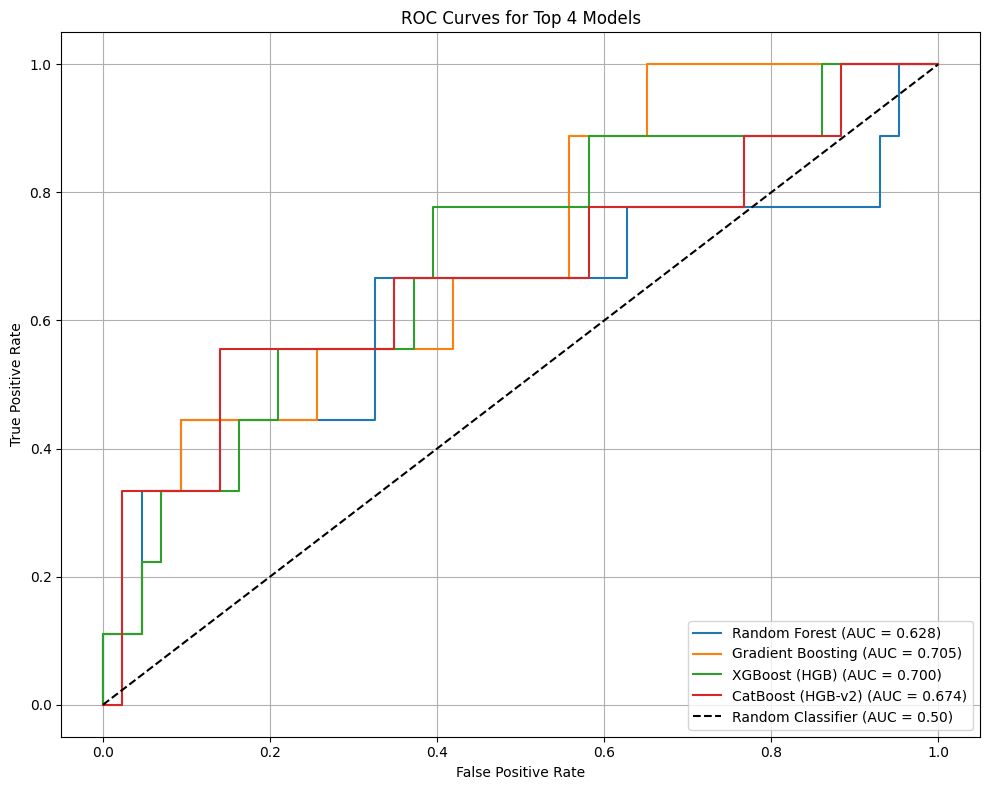

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

for name in top4_names:
    y_proba = results_top[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Top 4 Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Figure 5 — Confusion Matrix (Best Model: Random Forest)

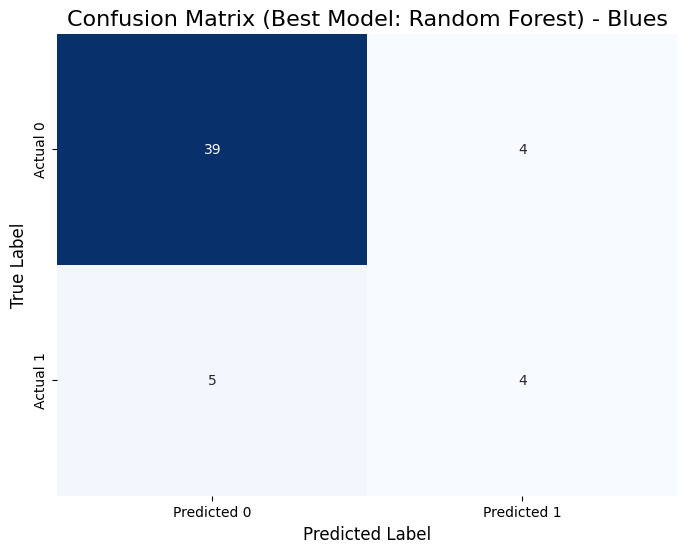

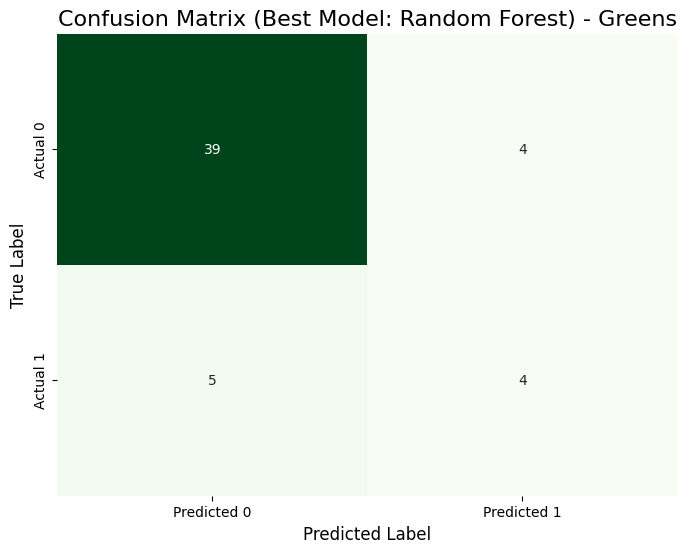

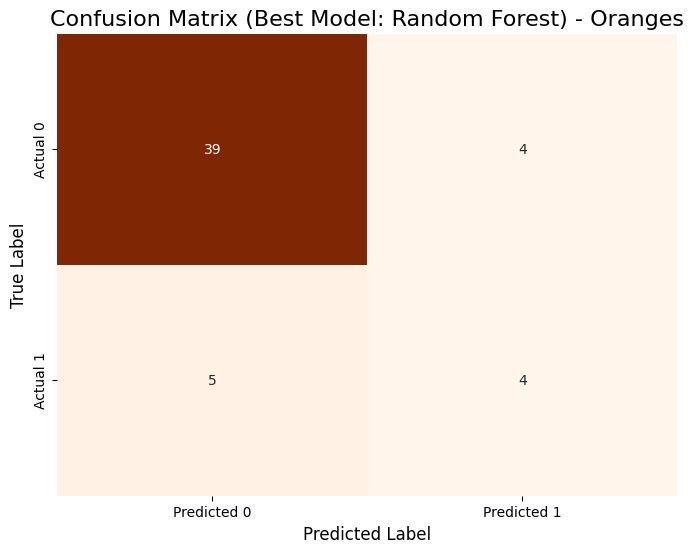

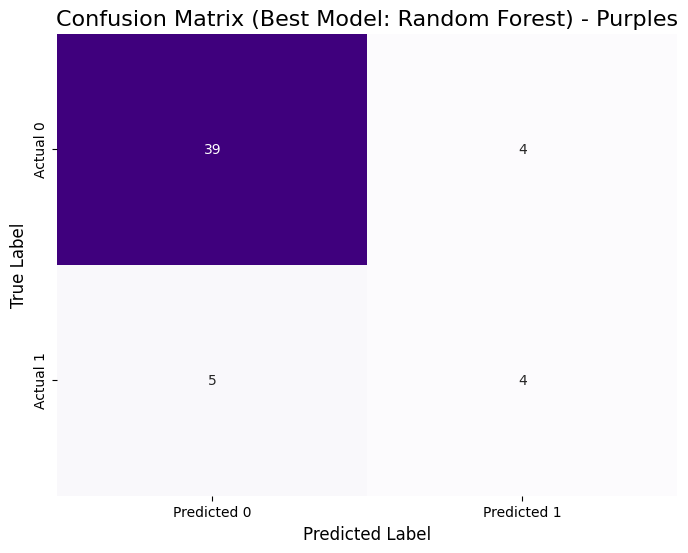

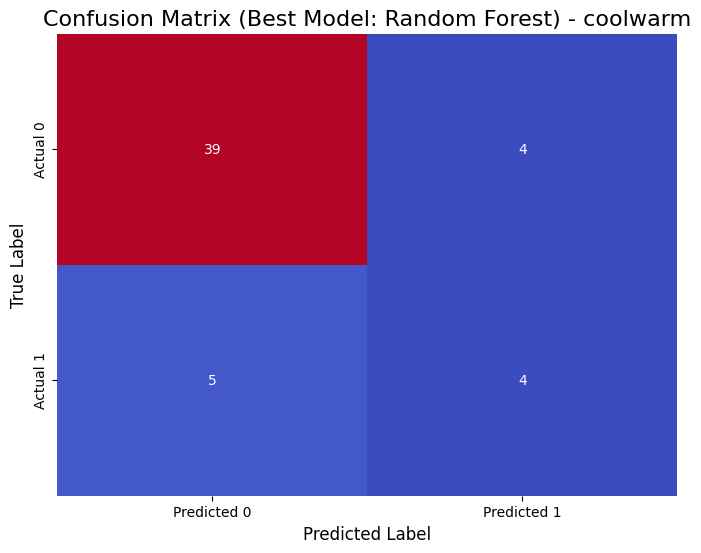

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Get predictions for the best model
y_pred_best_model = results_top[best_model_name]['y_pred']

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_best_model)

# Create a DataFrame for better labeling
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

# Different color maps to try
color_maps = ['Blues', 'Greens', 'Oranges', 'Purples', 'coolwarm']

for cmap in color_maps:
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap=cmap, cbar=False)
    plt.title(f'Confusion Matrix (Best Model: {best_model_name}) - {cmap}', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

## 12. SHAP Analysis — Best Model (Random Forest)

Permutation-based SHAP values computed on the test set.  
- **Red bars** → feature increases dropout risk  
- **Blue bars** → feature decreases dropout risk

In [25]:
def simple_shap_values(model, X, n_repeats=30, random_state=42):
    rng = np.random.RandomState(random_state)
    baseline = model.predict_proba(X)[:,1]
    shap_vals = np.zeros_like(X, dtype=float)
    for j in range(X.shape[1]):
        marginal = np.zeros(len(X))
        for _ in range(n_repeats):
            Xp = X.copy(); Xp[:,j] = rng.permutation(Xp[:,j])
            marginal += baseline - model.predict_proba(Xp)[:,1]
        shap_vals[:,j] = marginal / n_repeats
    return shap_vals

top10_feat_names = [feature_names_proc[i] for i in feat_idx[:10]]
shap_values = simple_shap_values(fitted_models_top[best_model_name],
                                  X_test_top, n_repeats=30, random_state=SEED)
shap_mean_abs = np.abs(shap_values).mean(axis=0)
print('✔ SHAP values computed')
print('Top features by |SHAP|:')
for i in np.argsort(shap_mean_abs)[::-1]:
    print(f'  {top10_feat_names[i]:40s}  {shap_mean_abs[i]:.5f}')

✔ SHAP values computed
Top features by |SHAP|:
  screen_time_1–2 hours / ১–২ ঘণ্টা         0.06564
  family_support                            0.05786
  semester_break_thought                    0.05673
  stress_total                              0.03458
  current_cgpa_num                          0.03327
  pressure_for_marriage                     0.03039
  teacher_support                           0.02859
  screen_time_2–4 hours / ২–৪ ঘণ্টা         0.02628
  continue_study_if_married                 0.02463
  academic_backlog_Yes                      0.02123


### Figure 6 — SHAP Summary (Directional Importance)

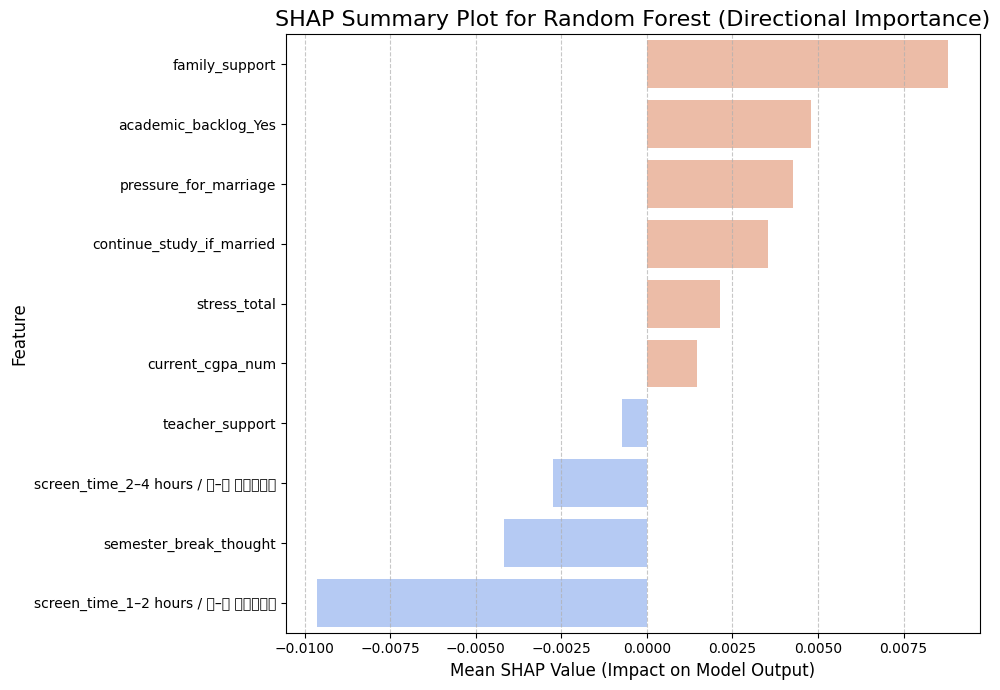

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for SHAP values with feature names
shap_df = pd.DataFrame(shap_values, columns=top10_feat_names)

# Calculate the mean SHAP value for each feature
mean_shap_values = shap_df.mean().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=mean_shap_values.values, y=mean_shap_values.index, palette='coolwarm', hue=mean_shap_values.values > 0, legend=False)
plt.title(f'SHAP Summary Plot for {best_model_name} (Directional Importance)', fontsize=16)
plt.xlabel('Mean SHAP Value (Impact on Model Output)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Figure 7 — SHAP Scatter (Per-Feature Impact)

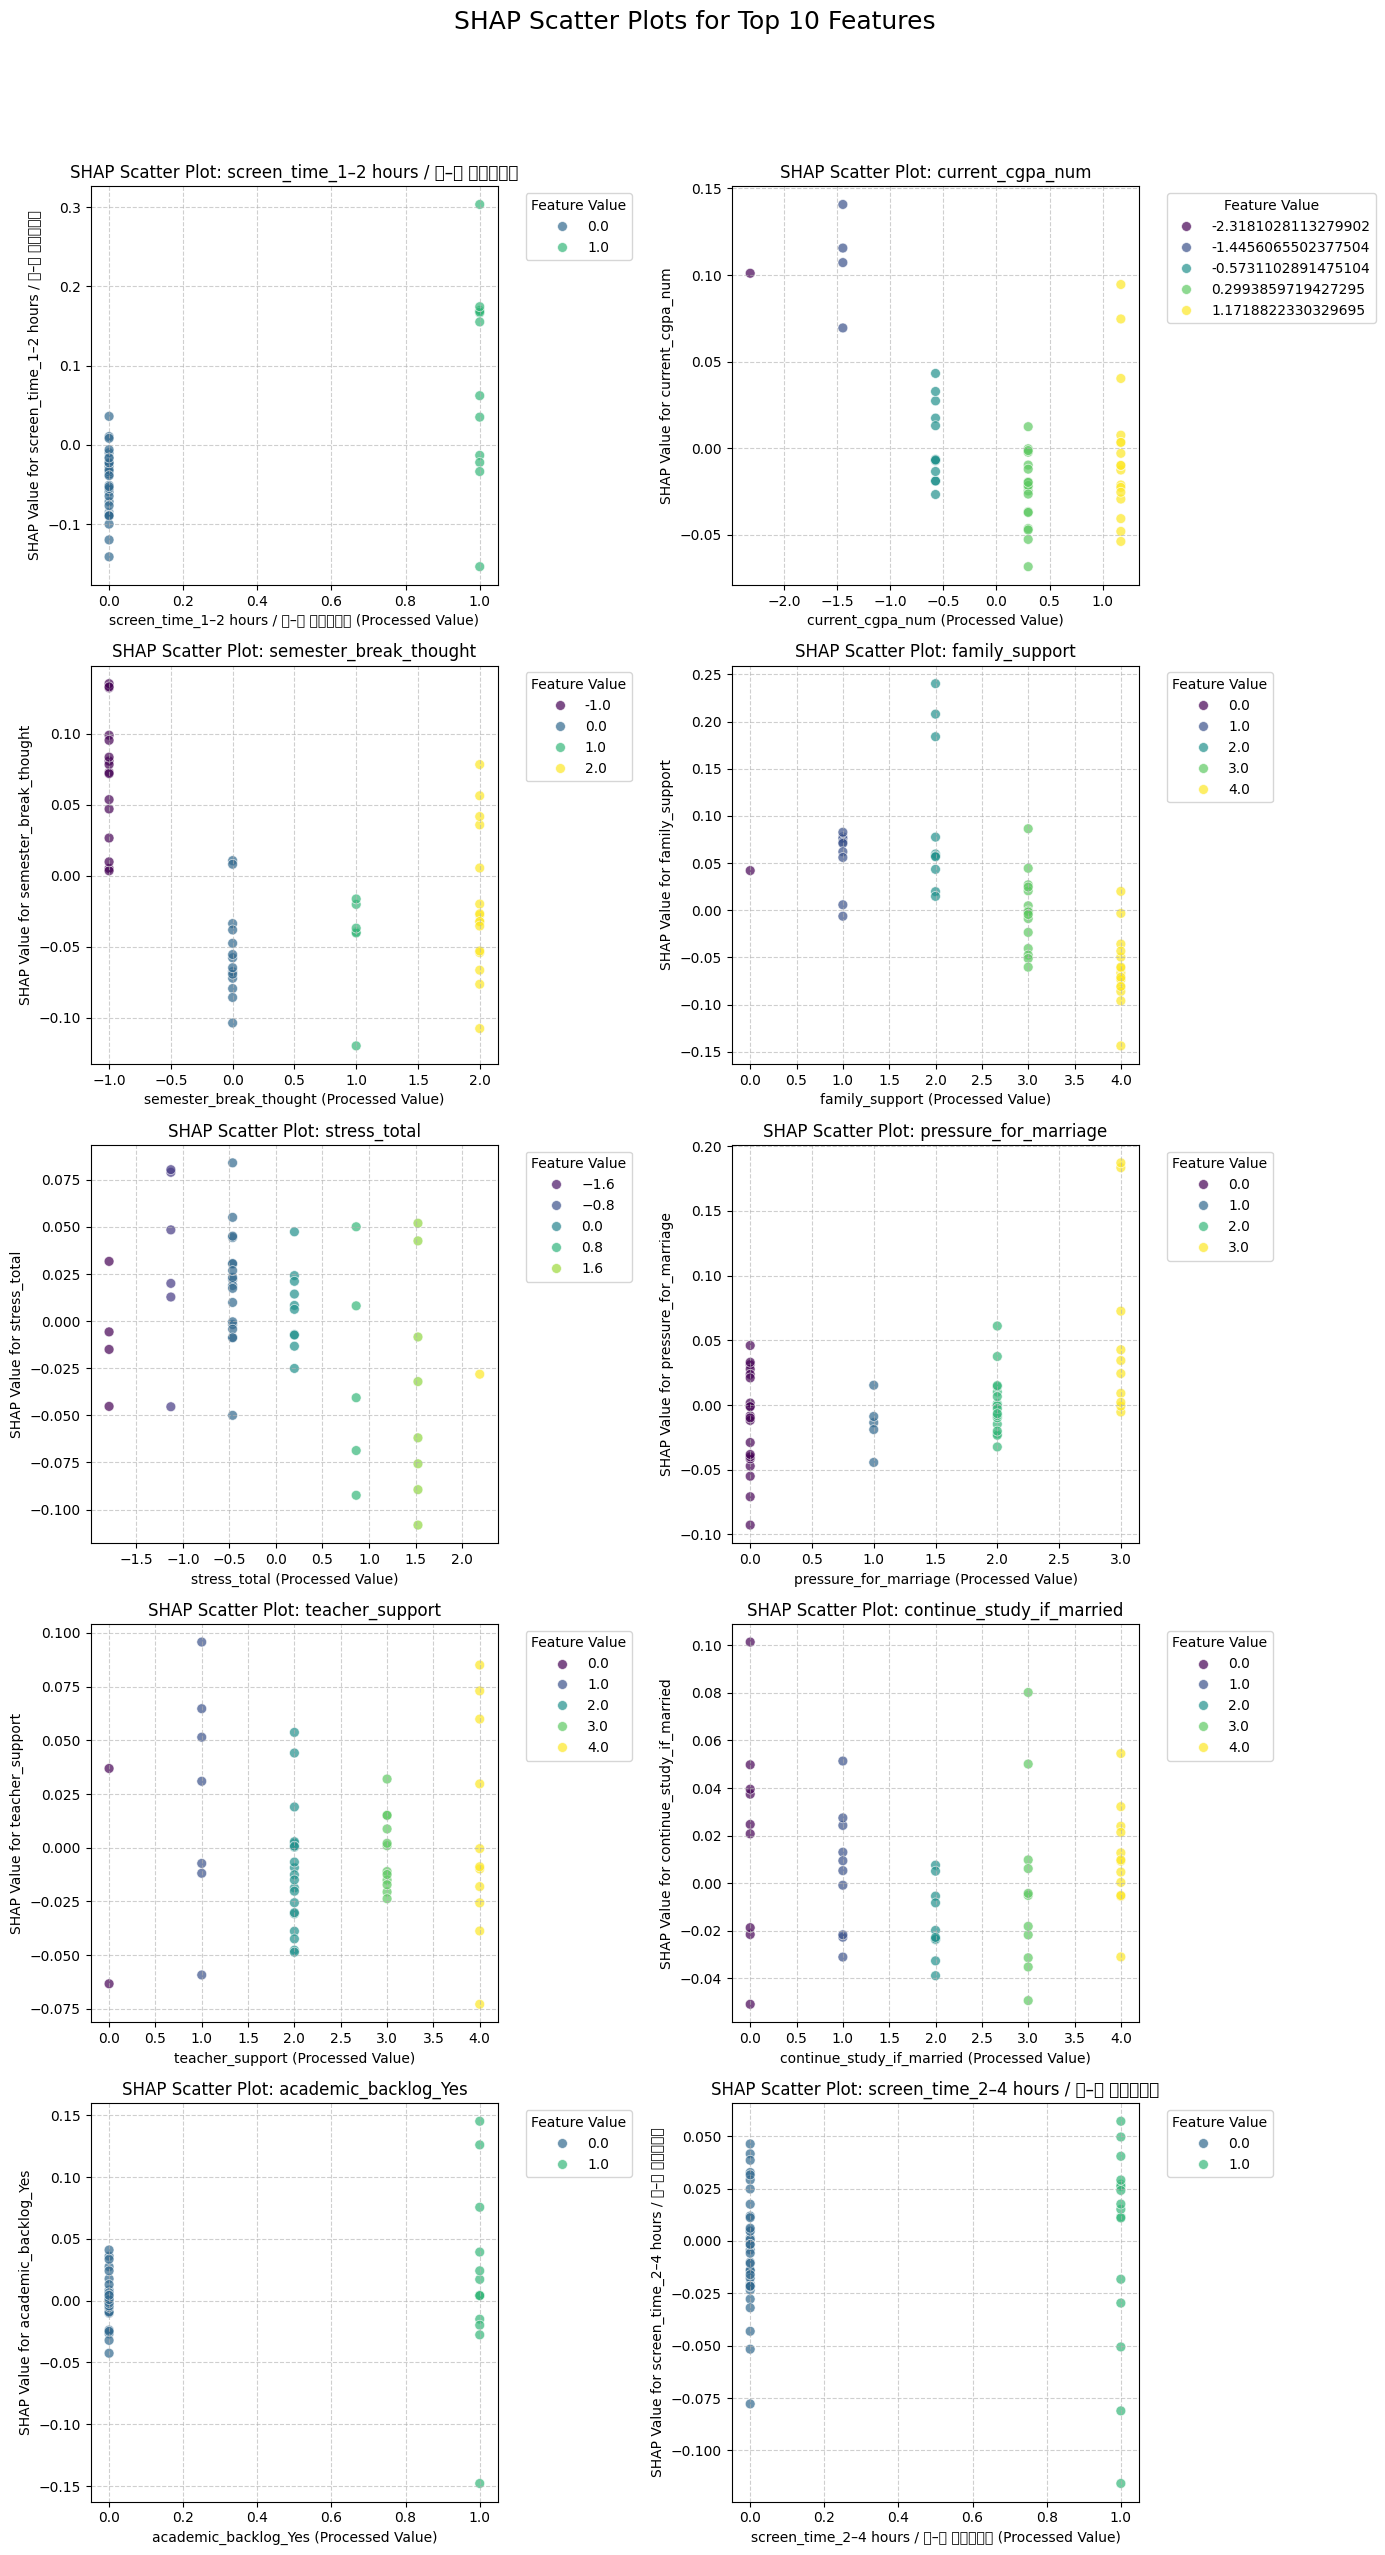

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume shap_values, X_test_top, top10_feat_names are available from previous cells.

# Create a DataFrame for easier plotting, using the processed feature values
X_test_top_df = pd.DataFrame(X_test_top, columns=top10_feat_names)

# Determine grid dimensions for subplots
num_features = len(top10_feat_names)
num_cols = 2
num_rows = (num_features + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 7, num_rows * 5)) # Adjust figure size dynamically
plt.suptitle('SHAP Scatter Plots for Top 10 Features', y=1.02, fontsize=18)

for i, feature_name in enumerate(top10_feat_names):
    plt.subplot(num_rows, num_cols, i + 1)

    # Use a scatter plot for SHAP value vs. feature value
    sns.scatterplot(
        x=X_test_top_df[feature_name],
        y=shap_values[:, i], # SHAP values for the current feature
        hue=X_test_top_df[feature_name], # Color by feature value itself
        palette='viridis',
        s=50, # Marker size
        alpha=0.7
    )

    plt.title(f'SHAP Scatter Plot: {feature_name}', fontsize=12)
    plt.xlabel(f'{feature_name} (Processed Value)', fontsize=10)
    plt.ylabel(f'SHAP Value for {feature_name}', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Adjust legend for categorical vs. continuous-like features
    if len(X_test_top_df[feature_name].unique()) < 10: # Heuristic for categorical-like data
        plt.legend(title='Feature Value', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.legend([],[], frameon=False) # Remove legend for continuous features to avoid clutter

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## 15. Best Model Performance on Test Data


--- Performance for Best Model: Random Forest ---

Accuracy:  0.827
Precision: 0.500
Recall:    0.444
F1-Score:  0.471
ROC-AUC:   0.628

--- Classification Report ---

              precision    recall  f1-score   support

 Not Dropout       0.89      0.91      0.90        43
     Dropout       0.50      0.44      0.47         9

    accuracy                           0.83        52
   macro avg       0.69      0.68      0.68        52
weighted avg       0.82      0.83      0.82        52



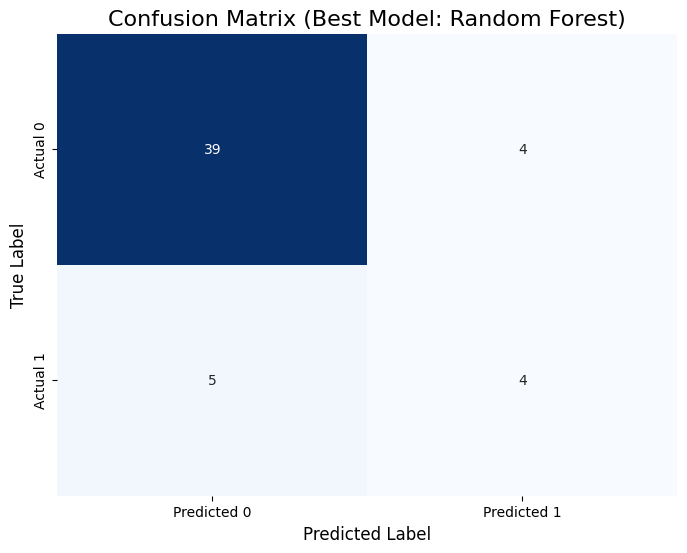

In [28]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Get the best model and its predictions from results_top
best_model = fitted_models_top[best_model_name]
y_pred_best = results_top[best_model_name]['y_pred']
y_proba_best = results_top[best_model_name]['y_proba']

print(f'\n--- Performance for Best Model: {best_model_name} ---\n')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_best):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_best, zero_division=0):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred_best, zero_division=0):.3f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_best, zero_division=0):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba_best):.3f}')

print('\n--- Classification Report ---\n')
print(classification_report(y_test, y_pred_best, target_names=['Not Dropout', 'Dropout']))

# Display the confusion matrix again for convenience
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Best Model: {best_model_name})', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

## 13. Final Performance Summary

In [29]:
rows = []
for name, res in sorted(results_top.items(), key=lambda x: x[1]['f1'], reverse=True):
    rows.append({'Model': name,
                 'Accuracy': round(res['accuracy'],3),
                 'Precision': round(res['precision'],3),
                 'Recall': round(res['recall'],3),
                 'F1-Score': round(res['f1'],3),
                 'ROC-AUC': round(res['roc_auc'],3),
                 'In Top 4': '✦' if name in top4_names else ''})
perf_df = pd.DataFrame(rows).set_index('Model')
print(perf_df.to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC In Top 4
Model                                                                       
Random Forest           0.827      0.500   0.444     0.471    0.628        ✦
Gradient Boosting       0.827      0.500   0.444     0.471    0.705        ✦
XGBoost (HGB)           0.827      0.500   0.333     0.400    0.700        ✦
CatBoost (HGB-v2)       0.808      0.429   0.333     0.375    0.674        ✦
Logistic Regression     0.673      0.278   0.556     0.370    0.612         
SVM                     0.731      0.308   0.444     0.364    0.682         
